# Clase 07 — Ejercicio guiado: implementa una red neuronal paso a paso
### Universidad EAFIT | SI3003 — Introducción a la Inteligencia Artificial

---

En el notebook `YourFirstDeepNN.ipynb` *usamos* una red neuronal: PyTorch construyó las capas,
calculó los gradientes y actualizó los pesos por nosotros. Aquí vamos a hacer lo contrario:
**vamos a escribir nosotros cada pieza**, con NumPy, para que no quede ninguna caja negra.

Al terminar habrás implementado, con tus propias manos:

| Pieza | Qué es | Dónde apareció en clase |
|---|---|---|
| Inicialización de pesos | los parámetros $\mathbf{W}, \mathbf{b}$ | Regresión lineal: $\hat{y}=\mathbf{w}^T\mathbf{x}$ |
| Funciones de activación | la no linealidad $g$ | Sigmoide, ReLU |
| *Forward pass* | calcular $\hat{y}$ | Propagación hacia adelante |
| Función de costo | medir el error $\mathcal{L}$ | Entropía cruzada |
| *Backward pass* | calcular $\partial\mathcal{L}/\partial \mathbf{W}$ | **Backpropagation** |
| Ciclo de entrenamiento | $\mathbf{W} \leftarrow \mathbf{W} - \alpha\,\nabla\mathcal{L}$ | Descenso por el gradiente |

> **La receta de toda la clase 7**: *modelo* + *función de costo* + *entrenamiento*.
> Regresión lineal, perceptrón y red profunda son la misma receta cambiando quién es el modelo.
> Este notebook la construye completa, una línea a la vez.

---

## Cómo trabajar este notebook

- Las celdas marcadas con `# TODO` son **tuyas**: están incompletas a propósito.
- Después de casi cada `TODO` hay una **celda de validación** con `assert`. Si imprime `✓`, tu
  implementación es correcta y puedes seguir. Si falla, revisa esa celda antes de continuar.
- No borres las celdas de validación: son tu red de seguridad. Un error en el *backward pass*
  es prácticamente invisible (el modelo simplemente entrena "un poco peor"), y por eso vamos a
  verificarlo numéricamente.
- Al final hay **preguntas de cierre**. Respóndelas en las celdas de texto habilitadas.

---

---
## 0. Configuración del entorno

Solo necesitamos **NumPy** (álgebra lineal), **Matplotlib** (gráficas) y **scikit-learn**
(únicamente para generar el dataset y partirlo en entrenamiento/prueba).

Fijamos una **semilla aleatoria** para que todos en la clase obtengamos exactamente los mismos
números y podamos comparar resultados.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

SEED = 42                      # Semilla: hace reproducible todo lo aleatorio (datos e inicialización)
np.random.seed(SEED)

print(f'NumPy      : {np.__version__}')
print(f'Semilla fija: {SEED}')

NumPy      : 2.2.0
Semilla fija: 42


---
## 1. El dataset *toy*: "dos lunas"

Vamos a usar `make_moons`: dos grupos de puntos en forma de media luna entrelazadas.

¿Por qué este dataset y no MNIST?

1. **Vive en 2 dimensiones** ($x_1, x_2$), así que podemos **dibujar la frontera de decisión**
   y *ver* literalmente lo que la red aprendió. Con 784 dimensiones eso es imposible.
2. **No es linealmente separable**: ninguna recta deja todas las lunas de un lado. Es el mismo
   obstáculo del XOR que frenó al perceptrón (Minsky y Papert, 1969) y que motiva las capas ocultas.
3. Es pequeño: entrena en segundos, así que puedes experimentar muchas veces.

Es, de hecho, uno de los datasets de [playground.tensorflow.org](http://playground.tensorflow.org).

### Notación (la de la clase)

- $\mathbf{X} \in \Re^{n \times d}$: matriz de características, $n$ ejemplos (filas) y $d=2$ características (columnas).
- $y^{(i)} \in \{0, 1\}$: la etiqueta — a qué luna pertenece el punto $i$.

In [2]:
# Generamos 1000 puntos en dos medias lunas entrelazadas.
# noise=0.20 añade ruido gaussiano: sin él las lunas serían perfectas y el problema, demasiado fácil.
X, y = make_moons(n_samples=1000, noise=0.20, random_state=SEED)

# Guardamos y como columna (n, 1) en vez de vector plano (n,).
# Esto evita errores silenciosos de broadcasting cuando la comparemos con las predicciones (n, 1).
y = y.reshape(-1, 1).astype(np.float64)

print(f'Shape de X : {X.shape}   -> (n_ejemplos, d_features)')
print(f'Shape de y : {y.shape}   -> (n_ejemplos, 1)')
print(f'Clases     : {np.unique(y).astype(int)}  |  ejemplos por clase: {int((y==0).sum())} / {int((y==1).sum())}')
print(f'\nPrimeras 3 filas de X:\n{X[:3]}')
print(f'Sus etiquetas: {y[:3].ravel().astype(int)}')

Shape de X : (1000, 2)   -> (n_ejemplos, d_features)
Shape de y : (1000, 1)   -> (n_ejemplos, 1)
Clases     : [0 1]  |  ejemplos por clase: 500 / 500

Primeras 3 filas de X:
[[-0.11166654  0.52022374]
 [ 1.14264982 -0.34257734]
 [ 0.79555796 -0.01144231]]
Sus etiquetas: [1 1 1]


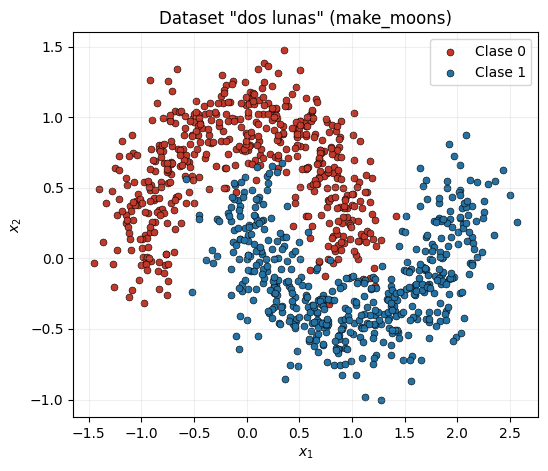

In [3]:
# Visualizamos el dataset completo: cada punto es un ejemplo, el color es su clase.
plt.figure(figsize=(6, 5))
plt.scatter(X[y.ravel() == 0, 0], X[y.ravel() == 0, 1], c='#c0392b', edgecolors='k',
            linewidths=0.4, s=25, label='Clase 0')
plt.scatter(X[y.ravel() == 1, 0], X[y.ravel() == 1, 1], c='#2471a3', edgecolors='k',
            linewidths=0.4, s=25, label='Clase 1')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.title('Dataset "dos lunas" (make_moons)')
plt.legend(); plt.grid(alpha=0.2)
plt.show()

> **Míralo antes de seguir.** Intenta trazar mentalmente **una sola recta** que deje todos los
> puntos rojos de un lado y todos los azules del otro. No existe. Ese es exactamente el límite
> del perceptrón, y la razón de ser de este notebook.

### Partición entrenamiento / prueba y estandarización

Dos prácticas que ya usamos en el notebook de MNIST y que aquí hacemos explícitas:

- **Partición**: el modelo se entrena con el 75% de los datos y se evalúa con el 25% restante,
  que **nunca ve durante el entrenamiento**. Sin esto no podemos detectar sobreajuste.
- **Estandarización**: transformamos cada característica a media $0$ y desviación estándar $1$:
  $$x_{\text{esc}} = \frac{x - \mu}{\sigma}$$
  El descenso por el gradiente converge mucho mejor cuando todas las características están en
  la misma escala (si una va de 0 a 1 y otra de 0 a 1000, el gradiente "zigzaguea").

> **Atención al detalle metodológico**: $\mu$ y $\sigma$ se calculan **solo con el conjunto de
> entrenamiento** y se aplican al de prueba. Usar el test para calcularlos sería *data leakage*:
> estaríamos filtrando información de datos que se supone que no hemos visto.

In [4]:
# stratify=y mantiene la misma proporción de clases en train y test.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

# Estandarización: la media y la desviación se estiman SOLO con el conjunto de entrenamiento.
mu    = X_train.mean(axis=0)
sigma = X_train.std(axis=0)

X_train = (X_train - mu) / sigma
X_test  = (X_test  - mu) / sigma      # se aplican los MISMOS mu y sigma del train

print(f'Entrenamiento : X {X_train.shape}, y {y_train.shape}')
print(f'Prueba        : X {X_test.shape}, y {y_test.shape}')
print(f'\nMedia por columna (train)   : {X_train.mean(axis=0).round(6)}  -> ~0')
print(f'Desviación por columna (train): {X_train.std(axis=0).round(6)}  -> ~1')

Entrenamiento : X (750, 2), y (750, 1)
Prueba        : X (250, 2), y (250, 1)

Media por columna (train)   : [-0. -0.]  -> ~0
Desviación por columna (train): [1. 1.]  -> ~1


---
## 2. Antes de la red: ¿hasta dónde llega un clasificador lineal?

Nunca empieces por el modelo complicado. Primero establece un **baseline**: el modelo más simple
que resuelve el problema. Aquí es el de la Parte 2 de la clase, un **clasificador lineal**
(regresión logística):

$$P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}\cdot\mathbf{x} + w_0), \qquad \sigma(z)=\frac{1}{1+e^{-z}}$$

Su frontera de decisión es $\mathbf{w}\cdot\mathbf{x} + w_0 = 0$: **una recta**. Ni más, ni menos.

Primero necesitamos una herramienta para *ver* fronteras de decisión. La función siguiente
evalúa el modelo en una malla densa de puntos que cubre todo el plano y colorea cada región según
la probabilidad predicha. **Esta celda te la damos hecha**: úsala tal cual durante todo el notebook.

In [5]:
def plot_decision_boundary(predict_proba, X, y, ax=None, title=''):
    """Dibuja la frontera de decisión de cualquier clasificador binario en 2D.

    predict_proba : función que recibe una matriz (m, 2) y devuelve (m,) o (m, 1)
                    con P(y=1 | x). Sirve para nuestra red y para cualquier modelo de sklearn.
    X, y          : puntos a dibujar encima de la frontera.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(5.5, 4.5))

    # 1) Malla de puntos que cubre el rango de los datos (con un margen).
    x0 = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 250)
    x1 = np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 250)
    XX, YY = np.meshgrid(x0, x1)
    grid = np.c_[XX.ravel(), YY.ravel()]          # (250*250, 2): la malla como matriz de features

    # 2) Pedimos al modelo la probabilidad en cada punto de la malla.
    Z = np.asarray(predict_proba(grid)).reshape(XX.shape)

    # 3) Color de fondo = probabilidad;  línea negra = frontera P(y=1) = 0.5
    ax.contourf(XX, YY, Z, levels=np.linspace(0, 1, 21), cmap='RdBu', alpha=0.75)
    ax.contour(XX, YY, Z, levels=[0.5], colors='k', linewidths=1.6)
    ax.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap='RdBu', edgecolors='k', s=22, linewidths=0.4)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.set_title(title)
    return ax

print('Función de visualización lista.')

Función de visualización lista.


Clasificador lineal - accuracy entrenamiento : 0.8587
Clasificador lineal - accuracy prueba        : 0.9040
Parámetros del modelo: 3  (w1, w2 y el sesgo w0)


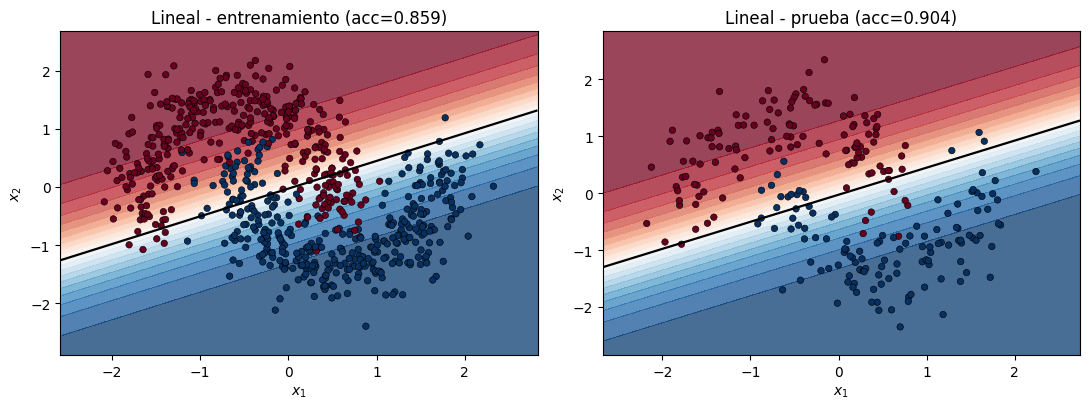

In [6]:
from sklearn.linear_model import LogisticRegression

# Baseline: un clasificador lineal (una sola neurona con sigmoide, sin capas ocultas).
baseline = LogisticRegression()
baseline.fit(X_train, y_train.ravel())

acc_tr_lin = baseline.score(X_train, y_train.ravel())
acc_te_lin = baseline.score(X_test,  y_test.ravel())

print(f'Clasificador lineal - accuracy entrenamiento : {acc_tr_lin:.4f}')
print(f'Clasificador lineal - accuracy prueba        : {acc_te_lin:.4f}')
print(f'Parámetros del modelo: {baseline.coef_.size + baseline.intercept_.size}'
      f'  (w1, w2 y el sesgo w0)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
plot_decision_boundary(lambda g: baseline.predict_proba(g)[:, 1], X_train, y_train, axes[0],
                       f'Lineal - entrenamiento (acc={acc_tr_lin:.3f})')
plot_decision_boundary(lambda g: baseline.predict_proba(g)[:, 1], X_test, y_test, axes[1],
                       f'Lineal - prueba (acc={acc_te_lin:.3f})')
plt.tight_layout(); plt.show()

**Observa la línea negra**: es recta, y no puede ser otra cosa. El modelo acierta alrededor del
86% de los casos de entrenamiento, pero se equivoca sistemáticamente justo donde las lunas se
entrelazan — y ahí no hay ajuste de pesos que lo salve: *el problema no es que esté mal entrenado,
es que su familia de hipótesis no contiene la solución*. Es la letra pequeña del teorema de
convergencia del perceptrón: **"si los datos son linealmente separables"**.

> Guarda ese número (`acc_te_lin`). Es la vara con la que vamos a medir la red neuronal.

---
## 3. La arquitectura que vamos a implementar

Una red *fully-connected* con **una capa oculta**:

```
   x (2)  --[W1,b1]-->  z1 (H)  --g(.)-->  a1 (H)  --[W2,b2]-->  z2 (1)  --sigma-->  y_hat
  entrada    lineal    pre-activación     activación    lineal      logit          probabilidad
```

En ecuaciones (en forma matricial, procesando los $n$ ejemplos de una sola vez):

$$
\begin{aligned}
\mathbf{Z}^{[1]} &= \mathbf{X}\,\mathbf{W}^{[1]} + \mathbf{b}^{[1]} \\
\mathbf{A}^{[1]} &= g\left(\mathbf{Z}^{[1]}\right) \\
\mathbf{Z}^{[2]} &= \mathbf{A}^{[1]}\,\mathbf{W}^{[2]} + \mathbf{b}^{[2]} \\
\hat{\mathbf{y}} = \mathbf{A}^{[2]} &= \sigma\left(\mathbf{Z}^{[2]}\right)
\end{aligned}
$$

### Las dimensiones (revísalas: el 90% de los errores en redes neuronales son de *shape*)

Con $n$ = número de ejemplos, $d=2$ entradas y $H$ neuronas ocultas:

| Objeto | Shape | Significado |
|---|---|---|
| $\mathbf{X}$ | $(n, d)$ | ejemplos por filas |
| $\mathbf{W}^{[1]}$ | $(d, H)$ | un peso por cada par (entrada, neurona oculta) |
| $\mathbf{b}^{[1]}$ | $(1, H)$ | un sesgo por neurona oculta |
| $\mathbf{Z}^{[1]}, \mathbf{A}^{[1]}$ | $(n, H)$ | **las características aprendidas** |
| $\mathbf{W}^{[2]}$ | $(H, 1)$ | un peso por neurona oculta |
| $\mathbf{b}^{[2]}$ | $(1, 1)$ | el sesgo de salida |
| $\hat{\mathbf{y}}$ | $(n, 1)$ | probabilidad de clase 1 por ejemplo |

> **La idea central de la clase**: $\mathbf{A}^{[1]}$ es la respuesta a la pregunta *"¿de dónde
> salen las características $f(x)$?"*. La capa oculta transforma el espacio de entrada en uno nuevo
> —de $H$ dimensiones— donde las dos lunas **sí** son linealmente separables. La capa de salida
> es, literalmente, la misma regresión logística de la sección 2, pero aplicada sobre las
> características que la red se inventó.

---
### 3.1 Inicialización de los parámetros

**TODO 1.** Crea el diccionario de parámetros. Reglas:

- **Pesos** $\mathbf{W}$: valores aleatorios de una normal centrada en 0. Usa la
  **inicialización de He**, pensada para ReLU: desviación estándar $\sqrt{2/n_{\text{entradas}}}$,
  donde $n_{\text{entradas}}$ es el número de entradas de esa capa ($d$ para `W1`, $H$ para `W2`).
- **Sesgos** $\mathbf{b}$: **ceros**. No hay problema en que empiecen todos iguales.

> **¿Por qué los pesos no pueden ser todos cero (o todos iguales)?**
> Si todas las neuronas de la capa oculta empiezan con los mismos pesos, calculan exactamente lo
> mismo en el *forward*, reciben exactamente el mismo gradiente en el *backward*, y se actualizan
> igual — para siempre. $H$ neuronas idénticas equivalen a **una sola**. Es el problema de la
> **simetría**, y la aleatoriedad es lo que la rompe.

Ayuda: `rng.normal(loc=0.0, scale=..., size=(filas, columnas))` y `np.zeros((1, H))`.

In [ ]:
def init_params(d, H, seed=SEED):
    """Inicializa los parámetros de la red d -> H -> 1.

    Devuelve un diccionario con las claves 'W1', 'b1', 'W2', 'b2'.
    """
    rng = np.random.default_rng(seed)   # generador propio: la inicialización es reproducible

    # TODO 1: completa las cuatro entradas respetando los shapes de la tabla de arriba.
    params = {
        'W1': ...,   # (d, H)  normal con std = sqrt(2/d)
        'b1': ...,   # (1, H)  ceros
        'W2': ...,   # (H, 1)  normal con std = sqrt(2/H)
        'b2': ...,   # (1, 1)  ceros
    }
    return params

In [ ]:
# --- Validación TODO 1 ---
_p = init_params(d=2, H=8)
assert set(_p.keys()) == {'W1', 'b1', 'W2', 'b2'}, 'Faltan claves en el diccionario'
assert _p['W1'].shape == (2, 8), f"W1 debe ser (2, 8), es {_p['W1'].shape}"
assert _p['b1'].shape == (1, 8), f"b1 debe ser (1, 8), es {_p['b1'].shape}"
assert _p['W2'].shape == (8, 1), f"W2 debe ser (8, 1), es {_p['W2'].shape}"
assert _p['b2'].shape == (1, 1), f"b2 debe ser (1, 1), es {_p['b2'].shape}"
assert np.allclose(_p['b1'], 0) and np.allclose(_p['b2'], 0), 'Los sesgos deben empezar en cero'
assert not np.allclose(_p['W1'], 0), 'Los pesos NO pueden ser cero: hay que romper la simetría'
assert len(np.unique(_p['W1'])) == _p['W1'].size, 'Los pesos deben ser todos distintos (aleatorios)'
assert abs(_p['W1'].std() - 1.0) < 0.9, 'Revisa la escala de la inicialización'

print('OK TODO 1 - parámetros inicializados con los shapes adecuados.')
print(f"\nW1 =\n{_p['W1'].round(3)}")
print(f"\nTotal de parámetros entrenables: {sum(v.size for v in _p.values())}")

---
### 3.2 Funciones de activación

**TODO 2.** Implementa las activaciones y **sus derivadas** (las necesitaremos en el *backward*).

$$
\text{ReLU}(z) = \max(0, z)
\qquad\qquad
\text{ReLU}'(z) = \begin{cases}1 & z > 0\\ 0 & z \le 0\end{cases}
$$

$$
\sigma(z) = \frac{1}{1+e^{-z}}
\qquad\qquad
\tanh'(z) = 1 - \tanh^2(z)
$$

También implementarás `identity` ($g(z)=z$, derivada $1$). Parece inútil — y esa es justamente la
gracia: en la sección 6 la usaremos para **quitarle la no linealidad a la red** y comprobar en vivo
lo que dicen las diapositivas: sin una $g$ no lineal, apilar capas no sirve absolutamente de nada.

> **Cuidado con el desbordamiento numérico.** Si $z = -1000$, `np.exp(-z)` = `np.exp(1000)` = `inf`
> y NumPy lanza un `RuntimeWarning`. Solución sencilla y estándar: recorta $z$ al rango
> $[-500, 500]$ con `np.clip` antes de exponenciar. La sigmoide ya vale prácticamente 0 y 1 mucho
> antes de esos valores, así que no perdemos nada.

Ayuda: `np.maximum(0.0, z)`, `(z > 0).astype(float)`, `np.tanh(z)`, `np.ones_like(z)`.

In [ ]:
def sigmoid(z):
    """Sigmoide, numéricamente estable. Devuelve valores en (0, 1)."""
    # TODO 2a: recorta z con np.clip(z, -500, 500) y aplica la fórmula.
    ...

def relu(z):
    """ReLU: max(0, z)."""
    # TODO 2b
    ...

def relu_grad(z):
    """Derivada de ReLU respecto a z: 1 si z > 0, 0 en caso contrario."""
    # TODO 2c
    ...

def tanh(z):
    """Tangente hiperbolica."""
    # TODO 2d
    ...

def tanh_grad(z):
    """Derivada de tanh: 1 - tanh(z)^2."""
    # TODO 2e
    ...

def identity(z):
    """Activación identidad: NO introduce no linealidad. La usaremos en el experimento A."""
    # TODO 2f
    ...

def identity_grad(z):
    """Derivada de la identidad: 1 en todo punto."""
    # TODO 2g
    ...


# Catálogo de activaciones: nombre -> (función, derivada).
# Nos permitirá cambiar la no linealidad de la red con un solo string.
ACTIVATIONS = {
    'relu':     (relu,     relu_grad),
    'tanh':     (tanh,     tanh_grad),
    'identity': (identity, identity_grad),
}

In [ ]:
# --- Validación TODO 2 ---
_z = np.array([-2.0, -0.5, 0.0, 0.5, 2.0])

assert np.allclose(relu(_z), [0, 0, 0, 0.5, 2]),        'relu incorrecta'
assert np.allclose(relu_grad(_z), [0, 0, 0, 1, 1]),     'relu_grad incorrecta'
assert abs(float(sigmoid(np.array([0.0]))[0]) - 0.5) < 1e-12, 'sigmoid(0) debe valer 0.5'
assert np.allclose(tanh(_z), np.tanh(_z)),              'tanh incorrecta'
assert np.allclose(tanh_grad(np.array([0.0])), [1.0]),  'tanh_grad(0) debe valer 1'
assert np.allclose(identity(_z), _z),                   'identity incorrecta'
assert np.allclose(identity_grad(_z), 1.0),             'identity_grad debe valer 1'

# Estabilidad numérica: no debe producir inf, nan ni warnings de overflow.
_extremos = sigmoid(np.array([-1000.0, 0.0, 1000.0]))
assert np.all(np.isfinite(_extremos)), 'sigmoid se desborda: usa np.clip'
assert _extremos[0] < 1e-6 and _extremos[2] > 1 - 1e-6, 'sigmoid mal en los extremos'

# Comprobamos numéricamente las derivadas (diferencias centradas).
for _g, _dg, _nm in [(relu, relu_grad, 'relu'), (tanh, tanh_grad, 'tanh')]:
    _pt  = np.array([-1.7, 0.9, 2.3])
    _num = (_g(_pt + 1e-6) - _g(_pt - 1e-6)) / 2e-6
    assert np.allclose(_num, _dg(_pt), atol=1e-5), f'la derivada de {_nm} no coincide con la numérica'

print('OK TODO 2 - activaciones y derivadas verificadas (incluso numéricamente).')

# Visualizamos las activaciones y sus derivadas.
_zz = np.linspace(-4, 4, 400)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for _nm, _fn in [('ReLU', relu), ('tanh', tanh), ('sigmoide', sigmoid), ('identidad', identity)]:
    axes[0].plot(_zz, _fn(_zz), label=_nm, lw=2)
for _nm, _fn in [("ReLU'", relu_grad), ("tanh'", tanh_grad), ("identidad'", identity_grad)]:
    axes[1].plot(_zz, _fn(_zz), label=_nm, lw=2)
axes[0].set_title('Funciones de activación'); axes[1].set_title('Sus derivadas')
axes[0].set_ylim(-2, 3)
for _a in axes:
    _a.axhline(0, color='k', lw=0.5); _a.axvline(0, color='k', lw=0.5)
    _a.grid(alpha=0.2); _a.legend(fontsize=8); _a.set_xlabel('$z$')
plt.tight_layout(); plt.show()

---
### 3.3 *Forward pass* — propagación hacia adelante

**TODO 3.** Implementa el paso hacia adelante siguiendo las cuatro ecuaciones de la sección 3.

Además de $\hat{\mathbf{y}}$, la función debe devolver un **caché** con los valores intermedios
$\mathbf{Z}^{[1]}, \mathbf{A}^{[1]}, \mathbf{Z}^{[2]}$. No es un capricho: el *backward pass*
los necesita, y recalcularlos sería un desperdicio. Guardar el caché del *forward* para reusarlo
en el *backward* es exactamente lo que hace `autograd` de PyTorch por dentro.

$$
\mathbf{Z}^{[1]} = \mathbf{X}\mathbf{W}^{[1]} + \mathbf{b}^{[1]}
\;\to\;
\mathbf{A}^{[1]} = g(\mathbf{Z}^{[1]})
\;\to\;
\mathbf{Z}^{[2]} = \mathbf{A}^{[1]}\mathbf{W}^{[2]} + \mathbf{b}^{[2]}
\;\to\;
\hat{\mathbf{y}} = \sigma(\mathbf{Z}^{[2]})
$$

Ayuda: el producto matricial en NumPy es `A @ B`. La suma del sesgo `(1, H)` a una matriz `(n, H)`
funciona sola gracias al *broadcasting*.

In [ ]:
def forward(X, params, activation='relu'):
    """Propagación hacia adelante de la red d -> H -> 1.

    Devuelve un diccionario 'cache' con Z1, A1, Z2 y A2 (= y_hat).
    """
    g, _ = ACTIVATIONS[activation]      # la derivada la usaremos en el backward

    # TODO 3: implementa las cuatro ecuaciones.
    Z1 = ...        # (n, H)
    A1 = ...        # (n, H)   características aprendidas
    Z2 = ...        # (n, 1)   logits
    A2 = ...        # (n, 1)   probabilidades P(y=1|x)

    return {'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A2': A2}

In [ ]:
# --- Validación TODO 3 ---
_p  = init_params(d=2, H=8)
_c  = forward(X_train, _p)

assert set(_c.keys()) >= {'Z1', 'A1', 'Z2', 'A2'}, 'El cache debe contener Z1, A1, Z2 y A2'
assert _c['Z1'].shape == (X_train.shape[0], 8), f"Z1 debería ser (n, 8), es {_c['Z1'].shape}"
assert _c['A1'].shape == (X_train.shape[0], 8), f"A1 debería ser (n, 8), es {_c['A1'].shape}"
assert _c['Z2'].shape == (X_train.shape[0], 1), f"Z2 debería ser (n, 1), es {_c['Z2'].shape}"
assert _c['A2'].shape == (X_train.shape[0], 1), f"A2 debería ser (n, 1), es {_c['A2'].shape}"
assert np.all((_c['A2'] > 0) & (_c['A2'] < 1)), 'A2 son probabilidades: deben estar en (0, 1)'
assert np.all(_c['A1'] >= 0), 'Con ReLU, A1 no puede tener valores negativos'

# Comprobación independiente de la primera fila, calculada "a mano".
_z1_manual = X_train[0] @ _p['W1'] + _p['b1'][0]
assert np.allclose(_c['Z1'][0], _z1_manual), 'Z1 no coincide con el cálculo manual'

print('OK TODO 3 - forward pass correcto.')
print(f"\nPrimeras 5 predicciones de la red SIN ENTRENAR: {_c['A2'][:5].ravel().round(3)}")
print(f"Probabilidad media predicha : {_c['A2'].mean():.3f}")
print(f"Aciertos con estos pesos al azar: {np.mean((_c['A2'] >= 0.5) == (y_train == 1)):.3f}")
print('\nEs prácticamente lo mismo que lanzar una moneda: los pesos son aleatorios')
print('y la red todavía no ha visto ni una sola etiqueta. Eso lo arregla el entrenamiento.')

---
### 3.4 La función de costo: entropía cruzada binaria

Para clasificación no usamos el error cuadrático medio de la regresión lineal, sino la
**entropía cruzada** (*cross-entropy*), la misma que usa `CrossEntropyLoss` de PyTorch pero en su
versión binaria:

$$\mathcal{L} = -\frac{1}{n}\sum_{i=1}^{n}\Big[ y^{(i)}\log \hat{y}^{(i)} + (1-y^{(i)})\log(1-\hat{y}^{(i)}) \Big]$$

Léela por partes, es más simple de lo que parece:

- Si $y^{(i)} = 1$, solo sobrevive el término $-\log \hat{y}^{(i)}$: el costo es $0$ si la red dijo
  $\hat{y}=1$, y tiende a $\infty$ si dijo $\hat{y}=0$.
- Si $y^{(i)} = 0$, solo sobrevive $-\log(1-\hat{y}^{(i)})$, simétricamente.

> **¿Por qué no error cuadrático?** Porque castiga muy poco la confianza equivocada. Si la red dice
> "probabilidad 0.99 de clase 1" y la etiqueta es 0, el error cuadrático vale $0.98$ (acotado),
> mientras que la entropía cruzada vale $4.6$ y sigue creciendo. Además, combinada con la sigmoide
> produce un gradiente mucho más limpio — lo veremos literalmente en el siguiente paso.

**TODO 4.** Implementa la función. Nota el `np.clip`: si $\hat{y}$ llegara exactamente a $0$ o $1$,
$\log(0) = -\infty$ arruinaría el entrenamiento. Recortar a $[\varepsilon, 1-\varepsilon]$ lo evita.

In [ ]:
def binary_cross_entropy(y_true, y_hat, eps=1e-12):
    """Entropía cruzada binaria promediada sobre los n ejemplos. Devuelve un escalar."""
    y_hat = np.clip(y_hat, eps, 1 - eps)     # evita log(0) = -inf

    # TODO 4: implementa la fórmula. Usa np.mean para promediar sobre los n ejemplos.
    ...


def accuracy(y_true, y_hat, umbral=0.5):
    """Fracción de aciertos. La predicción de clase es 1 si P(y=1|x) >= umbral."""
    y_pred = (y_hat >= umbral).astype(float)
    return float(np.mean(y_pred == y_true))

In [ ]:
# --- Validación TODO 4 ---
_y = np.array([[1.], [0.], [1.], [0.]])

# Caso 1: predicciones perfectas -> costo ~ 0
assert binary_cross_entropy(_y, np.array([[0.999999], [1e-6], [0.999999], [1e-6]])) < 1e-4, \
    'Con predicciones perfectas el costo debe ser casi 0'

# Caso 2: la red no sabe nada (0.5 en todo) -> costo = log(2) = 0.6931
assert abs(binary_cross_entropy(_y, np.full_like(_y, 0.5)) - np.log(2)) < 1e-9, \
    'Con y_hat = 0.5 el costo debe valer exactamente log(2) ~ 0.6931'

# Caso 3: predicciones seguras pero EQUIVOCADAS -> costo muy grande
assert binary_cross_entropy(_y, np.array([[1e-6], [0.999999], [1e-6], [0.999999]])) > 10, \
    'Equivocarse con confianza debe costar mucho'

assert accuracy(_y, np.array([[0.9], [0.1], [0.9], [0.6]])) == 0.75, 'accuracy incorrecta'

print('OK TODO 4 - función de costo y accuracy correctas.')
print(f'Costo de referencia (red sin entrenar, y_hat=0.5): {np.log(2):.4f}')
print('Si tu entrenamiento no baja de ~0.69, la red no está aprendiendo NADA.')

---
### 3.5 *Backward pass* — **backpropagation**

Aquí está el corazón del notebook. Necesitamos $\dfrac{\partial \mathcal{L}}{\partial \mathbf{W}}$
y $\dfrac{\partial \mathcal{L}}{\partial \mathbf{b}}$ para cada capa. Backpropagation **no es un
optimizador**: es la regla de la cadena aplicada de forma eficiente, propagando la derivada desde
la salida hacia la entrada y reutilizando cada resultado intermedio.

#### El regalo de la sigmoide con entropía cruzada

Si haces la derivada de $\mathcal{L}$ respecto a $\mathbf{Z}^{[2]}$ (encadenando la entropía
cruzada con la sigmoide), toda la expresión se simplifica hasta quedar en:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{Z}^{[2]}} = \frac{1}{n}\left(\hat{\mathbf{y}} - \mathbf{y}\right)$$

Es decir: **el gradiente en la salida es, simplemente, el error**. Comparen esto con la regla de
aprendizaje del perceptrón de la clase, $\mathbf{w} \leftarrow \mathbf{w} + \alpha(y - h_\mathbf{w}(\mathbf{x}))\mathbf{x}$:
es la misma estructura *peso ← peso − tasa × error × entrada*. No es coincidencia.

#### Las seis líneas que tienes que escribir

Recorriendo la red **de la salida hacia la entrada**:

$$
\begin{aligned}
\text{(1)}\quad d\mathbf{Z}^{[2]} &= \tfrac{1}{n}\left(\mathbf{A}^{[2]} - \mathbf{y}\right) & (n, 1)\\[2pt]
\text{(2)}\quad d\mathbf{W}^{[2]} &= \left(\mathbf{A}^{[1]}\right)^{T} d\mathbf{Z}^{[2]} & (H, 1)\\[2pt]
\text{(3)}\quad d\mathbf{b}^{[2]} &= \textstyle\sum_{\text{filas}} d\mathbf{Z}^{[2]} & (1, 1)\\[2pt]
\text{(4)}\quad d\mathbf{A}^{[1]} &= d\mathbf{Z}^{[2]} \left(\mathbf{W}^{[2]}\right)^{T} & (n, H)\\[2pt]
\text{(5)}\quad d\mathbf{Z}^{[1]} &= d\mathbf{A}^{[1]} \odot g'\!\left(\mathbf{Z}^{[1]}\right) & (n, H)\\[2pt]
\text{(6)}\quad d\mathbf{W}^{[1]} &= \mathbf{X}^{T} d\mathbf{Z}^{[1]}, \qquad d\mathbf{b}^{[1]} = \textstyle\sum_{\text{filas}} d\mathbf{Z}^{[1]} & (d, H),\ (1, H)
\end{aligned}
$$

Fíjate en el patrón, que se repite capa a capa:

- El paso **(4)** es *"pasar el error a la capa anterior"*: multiplicar por $\mathbf{W}^T$ es
  literalmente repartir la responsabilidad del error entre las neuronas que lo produjeron.
- El paso **(5)** es *"atravesar la activación"*: $\odot$ es el producto **elemento a elemento**
  (`*` en NumPy), **no** el producto matricial. Aquí es donde entra la derivada de $g$.
- Cada gradiente tiene **exactamente el mismo shape que su parámetro** — es la mejor forma de
  verificar que no te equivocaste al ordenar las transposiciones.

**TODO 5.** Implementa las seis líneas.

Ayuda: `A.T @ B` para el producto matricial con transpuesta, `A * B` para el producto elemento a
elemento, y `M.sum(axis=0, keepdims=True)` para sumar las filas conservando el shape `(1, k)`.

In [ ]:
def backward(X, y, params, cache, activation='relu'):
    """Backpropagation: calcula dL/dW y dL/db para las dos capas.

    Devuelve un diccionario 'grads' con las mismas claves que params.
    """
    _, g_prime = ACTIVATIONS[activation]     # derivada de la activación oculta
    n = X.shape[0]                           # número de ejemplos del batch

    # ---- Capa de salida ----------------------------------------------------
    dZ2 = ...        # (1) (n, 1)   el error, escalado por 1/n
    dW2 = ...        # (2) (H, 1)
    db2 = ...        # (3) (1, 1)

    # ---- Propagamos el error hacia la capa oculta ---------------------------
    dA1 = ...        # (4) (n, H)   reparto de responsabilidad
    dZ1 = ...        # (5) (n, H)   atravesamos la activación (producto elemento a elemento)

    # ---- Capa oculta -------------------------------------------------------
    dW1 = ...        # (6) (d, H)
    db1 = ...        # (6) (1, H)

    return {'W1': dW1, 'b1': db1, 'W2': dW2, 'b2': db2}

#### Verificación numérica del gradiente (*gradient checking*)

Un error en el *backward pass* casi nunca produce una excepción: la red simplemente entrena peor,
y es facilísimo culpar al *learning rate* en vez de al bug. Por eso, la técnica estándar es
comparar el gradiente analítico contra su **aproximación numérica** por diferencias centradas:

$$\frac{\partial \mathcal{L}}{\partial \theta} \approx \frac{\mathcal{L}(\theta + \varepsilon) - \mathcal{L}(\theta - \varepsilon)}{2\varepsilon}$$

Perturbamos **un parámetro a la vez**, recalculamos el costo y vemos cuánto cambió. Es carísimo
(un *forward* completo por parámetro y por dirección), así que se usa solo para depurar sobre una
red diminuta — pero es la prueba definitiva de que tu backprop está bien.

> Usamos `tanh` en la verificación, no ReLU: ReLU no es derivable en $z=0$ y la aproximación
> numérica falla justo ahí. Si tu implementación pasa con `tanh`, la fórmula es correcta.

In [ ]:
# --- Validación TODO 5: gradient checking ---
_p  = init_params(d=2, H=5, seed=0)
_Xs, _ys = X_train[:20], y_train[:20]     # red y muestra pequeñas: el chequeo es costoso
_act = 'tanh'                             # derivable en todo punto, a diferencia de ReLU

_c  = forward(_Xs, _p, _act)
_gr = backward(_Xs, _ys, _p, _c, _act)

# 1) Los shapes deben coincidir uno a uno con los de los parámetros.
for _k in _p:
    assert _gr[_k].shape == _p[_k].shape, \
        f'grad {_k} tiene shape {_gr[_k].shape} pero el parámetro es {_p[_k].shape}'

# 2) Gradiente numérico, parámetro por parámetro.
_eps, _peor = 1e-6, 0.0
for _k in _p:
    _num = np.zeros_like(_p[_k])
    _it  = np.nditer(_p[_k], flags=['multi_index'])
    while not _it.finished:
        _i   = _it.multi_index
        _old = _p[_k][_i]
        _p[_k][_i] = _old + _eps
        _lp = binary_cross_entropy(_ys, forward(_Xs, _p, _act)['A2'])
        _p[_k][_i] = _old - _eps
        _lm = binary_cross_entropy(_ys, forward(_Xs, _p, _act)['A2'])
        _p[_k][_i] = _old                       # restauramos el valor original
        _num[_i] = (_lp - _lm) / (2 * _eps)     # diferencias centradas
        _it.iternext()

    # Error relativo entre el gradiente analítico y el numérico.
    _err = np.max(np.abs(_num - _gr[_k])) / max(1e-12, np.max(np.abs(_num) + np.abs(_gr[_k])))
    _peor = max(_peor, _err)
    print(f'  {_k}: error relativo = {_err:.2e}   {"OK" if _err < 1e-6 else "<-- REVISAR"}')

assert _peor < 1e-6, 'El backward NO coincide con el gradiente numérico: revisa el TODO 5'
print(f'\nOK TODO 5 - backpropagation verificada (peor error relativo: {_peor:.2e}).')
print('Un error < 1e-6 significa que tus fórmulas analíticas son correctas.')

---
### 3.6 El ciclo de entrenamiento

Ya tenemos todas las piezas. El entrenamiento es el bucle de la Parte 1 de la clase, el
**descenso por el gradiente**:

$$\theta \leftarrow \theta - \alpha \, \frac{\partial \mathcal{L}}{\partial \theta}
\qquad \text{para cada } \theta \in \{\mathbf{W}^{[1]}, \mathbf{b}^{[1]}, \mathbf{W}^{[2]}, \mathbf{b}^{[2]}\}$$

Compáralo con el ciclo de PyTorch del notebook de MNIST — es exactamente el mismo, sin la magia:

| PyTorch | Aquí |
|---|---|
| `optimizer.zero_grad()` | (innecesario: no acumulamos gradientes) |
| `outputs = model(x)` | `cache = forward(X, params, act)` |
| `loss = criterion(outputs, y)` | `loss = binary_cross_entropy(y, cache['A2'])` |
| `loss.backward()` | `grads = backward(X, y, params, cache, act)` |
| `optimizer.step()` | `params[k] -= lr * grads[k]` |

**TODO 6.** Completa los cuatro pasos dentro del bucle.

> **Nota**: usamos *full-batch* (los 750 ejemplos en cada paso) porque el dataset es diminuto y así
> el ciclo queda lo más claro posible. En MNIST usábamos mini-batches; la única diferencia sería
> un bucle interno que recorre trozos de `X`.

In [ ]:
def train(X, y, X_val, y_val, H=8, activation='relu', lr=0.5, epochs=2000, seed=SEED, verbose=True):
    """Entrena la red con descenso por el gradiente (full-batch).

    Devuelve (params entrenados, historia de métricas).
    """
    params  = init_params(X.shape[1], H, seed)
    history = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # ---- Paso 1: forward pass sobre el conjunto de entrenamiento -------
        cache = ...

        # ---- Paso 2: calcular el costo -------------------------------------
        loss = ...

        # ---- Paso 3: backward pass (gradientes) ----------------------------
        grads = ...

        # ---- Paso 4: actualizar los parámetros -----------------------------
        # Recorre las claves de params y aplica  theta <- theta - lr * dtheta
        for k in params:
            ...

        # ---- Métricas (ya implementado) ------------------------------------
        cache_val = forward(X_val, params, activation)
        history['loss'].append(loss)
        history['acc'].append(accuracy(y, cache['A2']))
        history['val_loss'].append(binary_cross_entropy(y_val, cache_val['A2']))
        history['val_acc'].append(accuracy(y_val, cache_val['A2']))

        if verbose and (epoch % (epochs // 10) == 0 or epoch == epochs - 1):
            print(f"epoch {epoch:5d} | loss {loss:.4f} | acc {history['acc'][-1]:.4f} "
                  f"| val_loss {history['val_loss'][-1]:.4f} | val_acc {history['val_acc'][-1]:.4f}")

    return params, history

In [ ]:
# --- Validación TODO 6 (entrenamiento corto de prueba) ---
_pp, _hh = train(X_train, y_train, X_test, y_test, H=8, epochs=200, lr=0.5, verbose=False)

assert len(_hh['loss']) == 200, 'La historia debe tener una entrada por epoch'
assert _hh['loss'][-1] < _hh['loss'][0], 'El costo debería BAJAR durante el entrenamiento'
assert _hh['loss'][-1] < 0.60, ('El costo apenas bajo de log(2)=0.69: revisa el paso de '
                                'actualización (el signo menos) o el forward')
assert _hh['acc'][-1] > 0.85, 'Tras 200 epochs el accuracy debería superar 0.85'

print(f"OK TODO 6 - el entrenamiento funciona.")
print(f"  costo   : {_hh['loss'][0]:.4f}  ->  {_hh['loss'][-1]:.4f}")
print(f"  accuracy: {_hh['acc'][0]:.4f}  ->  {_hh['acc'][-1]:.4f}")

---
## 4. Entrenamos la red completa

Con todas las piezas verificadas, entrenamos en serio: $H=8$ neuronas ocultas, activación ReLU,
$\alpha = 0.5$ y 2000 épocas.

In [ ]:
params_nn, hist_nn = train(
    X_train, y_train, X_test, y_test,
    H=8, activation='relu', lr=0.5, epochs=2000, verbose=True
)

n_params = sum(v.size for v in params_nn.values())
print(f'\nParámetros entrenables: {n_params}  (frente a los 3 del clasificador lineal)')

### 4.1 Las curvas de aprendizaje

Las curvas de costo y *accuracy* son la primera herramienta de diagnóstico de cualquier
entrenamiento. Qué mirar:

- El **costo de entrenamiento** debe bajar de forma sostenida. Si oscila o explota, el
  *learning rate* es demasiado grande. Si apenas se mueve, es demasiado pequeño.
- La **brecha** entre la curva de entrenamiento y la de prueba mide el **sobreajuste**: si la de
  entrenamiento sigue bajando mientras la de prueba empieza a subir, la red está memorizando.
  El momento en que eso empieza es donde haríamos *early stopping*.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(hist_nn['loss'], label='entrenamiento', lw=2)
axes[0].plot(hist_nn['val_loss'], label='prueba', lw=2)
axes[0].axhline(np.log(2), color='gray', ls='--', lw=1, label='costo de "no saber nada" = log 2')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('entropía cruzada')
axes[0].set_title('Curva de costo'); axes[0].legend(); axes[0].grid(alpha=0.2)

axes[1].plot(hist_nn['acc'], label='entrenamiento', lw=2)
axes[1].plot(hist_nn['val_acc'], label='prueba', lw=2)
axes[1].axhline(acc_te_lin, color='#c0392b', ls='--', lw=1.5,
                label=f'baseline lineal ({acc_te_lin:.3f})')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy')
axes[1].set_title('Curva de accuracy'); axes[1].legend(); axes[1].grid(alpha=0.2)

plt.tight_layout(); plt.show()

print(f"Accuracy final - entrenamiento : {hist_nn['acc'][-1]:.4f}")
print(f"Accuracy final - prueba        : {hist_nn['val_acc'][-1]:.4f}")
print(f"Baseline lineal (prueba)       : {acc_te_lin:.4f}")

### 4.2 La frontera de decisión: lineal vs. red neuronal

Este es el momento del notebook. Comparamos, sobre los **mismos datos de prueba**, la frontera que
podía trazar el clasificador lineal contra la que aprendió la red.

In [ ]:
# Envolvemos el forward en una función que devuelve solo P(y=1|x): es lo que espera el graficador.
def nn_predict_proba(grid, params=None, activation='relu'):
    params = params_nn if params is None else params
    return forward(grid, params, activation)['A2'].ravel()

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))
plot_decision_boundary(lambda g: baseline.predict_proba(g)[:, 1], X_test, y_test, axes[0],
                       f'Clasificador lineal (acc={acc_te_lin:.3f})')
plot_decision_boundary(nn_predict_proba, X_test, y_test, axes[1],
                       f"Red neuronal 2-8-1 (acc={hist_nn['val_acc'][-1]:.3f})")
plt.tight_layout(); plt.show()

> **Mira la forma de la frontera de la derecha.** Está compuesta por **tramos rectos**: es la
> huella de ReLU, que es lineal a trozos. Cada neurona oculta aporta un "pliegue", y al combinarlos
> la red construye una frontera curva por partes. Con más neuronas, más pliegues, y la curva se
> ve más suave.
>
> Esa es la intuición detrás del **teorema de aproximación universal**: con suficientes neuronas
> puedes aproximar cualquier función continua tanto como quieras.

### 4.3 ¿Qué aprendió cada neurona oculta?

Cada neurona oculta $j$ calcula $z_j = w_{1j}x_1 + w_{2j}x_2 + b_j$, y su ReLU se "activa" solo
del lado positivo de la recta $z_j = 0$. Es decir: **cada neurona oculta es un perceptrón**, y
dibuja una recta en el espacio de entrada. Vamos a superponer esas $H$ rectas sobre la frontera
final para ver de dónde salen los pliegues.

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
plot_decision_boundary(nn_predict_proba, X_test, y_test, ax, 'Las 8 rectas de la capa oculta')

# Para cada neurona j dibujamos su recta w1*x1 + w2*x2 + b = 0.
_x1 = np.linspace(X_test[:, 0].min() - 0.5, X_test[:, 0].max() + 0.5, 10)
for j in range(params_nn['W1'].shape[1]):
    w1, w2 = params_nn['W1'][0, j], params_nn['W1'][1, j]
    b      = params_nn['b1'][0, j]
    if abs(w2) > 1e-8:
        ax.plot(_x1, -(w1 * _x1 + b) / w2, '--', lw=1.2, alpha=0.9, color='k')
ax.set_ylim(X_test[:, 1].min() - 0.5, X_test[:, 1].max() + 0.5)
plt.tight_layout(); plt.show()

print('Cada línea punteada es una neurona oculta: un clasificador lineal (un perceptrón).')
print('La frontera curva de la red es la COMBINACIÓN de esas rectas, y esa combinación')
print('solo es posible porque ReLU corta la parte negativa de cada una.')

---
## 5. Diagnóstico: matriz de confusión y los casos difíciles

*Accuracy* es un solo número y esconde información. Veamos **dónde** se equivoca la red.

In [ ]:
proba_test = forward(X_test, params_nn, 'relu')['A2']
pred_test  = (proba_test >= 0.5).astype(float)

# Matriz de confusión 2x2, calculada a mano para ver de dónde sale cada celda.
VN = int(np.sum((pred_test == 0) & (y_test == 0)))   # verdaderos negativos
FP = int(np.sum((pred_test == 1) & (y_test == 0)))   # falsos positivos
FN = int(np.sum((pred_test == 0) & (y_test == 1)))   # falsos negativos
VP = int(np.sum((pred_test == 1) & (y_test == 1)))   # verdaderos positivos

print('Matriz de confusión (conjunto de prueba)')
print('                  pred 0    pred 1')
print(f'  real 0        {VN:7d}   {FP:7d}')
print(f'  real 1        {FN:7d}   {VP:7d}')
print(f'\nAccuracy  : {(VP + VN) / len(y_test):.4f}')
print(f'Precisión : {VP / max(1, VP + FP):.4f}   (de lo que predije como 1, cuánto era 1)')
print(f'Recall    : {VP / max(1, VP + FN):.4f}   (de los 1 reales, cuántos encontré)')

# Los errores, y su nivel de confianza.
err = (pred_test != y_test).ravel()
plt.figure(figsize=(6, 5))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test.ravel(), cmap='RdBu',
            edgecolors='k', linewidths=0.3, s=25, alpha=0.55)
plt.scatter(X_test[err, 0], X_test[err, 1], marker='x', s=150, c='lime', linewidths=2.5,
            label=f'errores ({int(err.sum())})')
plt.title('Dónde se equivoca la red'); plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.legend(); plt.grid(alpha=0.2); plt.show()

print('\nConfianza de la red en los ejemplos que falló (P(y=1|x)):')
print(np.round(proba_test[err].ravel(), 3))

---
## 6. Experimentos guiados

Ahora que la red funciona, la usamos como laboratorio. **Antes de ejecutar cada celda, escribe tu
predicción.** Equivocarte prediciendo es la forma más rápida de aprender qué hace cada
hiperparámetro.

---
### Experimento A — Quitarle la no linealidad (el más importante)

Las diapositivas afirman: *sin una activación no lineal, apilar capas no aporta nada, porque
$W_3(W_2(W_1x)) = (W_3W_2W_1)x = Wx$*. Vamos a comprobarlo.

Entrenamos exactamente la misma red 2→8→1, con los mismos 33 parámetros, la misma inicialización
y el mismo optimizador — cambiando **solo** `activation='identity'`.

**Predice primero**: ¿qué accuracy alcanzará? ¿Qué forma tendrá su frontera de decisión?

In [ ]:
params_lin, hist_lin = train(X_train, y_train, X_test, y_test,
                             H=8, activation='identity', lr=0.5, epochs=2000, verbose=False)

print(f"Red 2-8-1 CON ReLU      -> accuracy prueba: {hist_nn['val_acc'][-1]:.4f}")
print(f"Red 2-8-1 SIN activación -> accuracy prueba: {hist_lin['val_acc'][-1]:.4f}")
print(f"Regresión logística (3 parámetros, 1 capa) -> accuracy prueba: {acc_te_lin:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))
plot_decision_boundary(lambda g: nn_predict_proba(g, params_lin, 'identity'), X_test, y_test,
                       axes[0], f"g = identidad (acc={hist_lin['val_acc'][-1]:.3f})")
plot_decision_boundary(nn_predict_proba, X_test, y_test, axes[1],
                       f"g = ReLU (acc={hist_nn['val_acc'][-1]:.3f})")
plt.tight_layout(); plt.show()

**Comprobación algebraica.** Si $g$ es la identidad, la red calcula
$\sigma\big((\mathbf{X}\mathbf{W}^{[1]} + \mathbf{b}^{[1]})\mathbf{W}^{[2]} + \mathbf{b}^{[2]}\big)
= \sigma\big(\mathbf{X}\underbrace{\mathbf{W}^{[1]}\mathbf{W}^{[2]}}_{\text{una sola matriz } (d,1)} + \text{const}\big)$.

Los 33 parámetros colapsan en 3 números efectivos. Vamos a verlo:

In [ ]:
# Si g = identidad, toda la red equivale a un único vector de pesos w_eq y un sesgo b_eq.
w_eq = params_lin['W1'] @ params_lin['W2']                              # (d, 1)
b_eq = params_lin['b1'] @ params_lin['W2'] + params_lin['b2']           # (1, 1)

print(f'Pesos equivalentes w_eq : {w_eq.ravel().round(4)}')
print(f'Sesgo equivalente  b_eq : {b_eq.ravel().round(4)}')

# Comprobamos que la red "profunda" y el modelo lineal equivalente dan lo MISMO.
pred_red   = forward(X_test, params_lin, 'identity')['A2']
pred_equiv = sigmoid(X_test @ w_eq + b_eq)
assert np.allclose(pred_red, pred_equiv), 'deberían ser idénticas'

print('\nLas predicciones de la red de 8 neuronas y las del modelo lineal de 3 parámetros')
print('coinciden hasta el último decimal. La profundidad, sin no linealidad, es una ilusión.')
print(f'Diferencia máxima: {np.max(np.abs(pred_red - pred_equiv)):.2e}')

---
### Experimento B — ¿Cuántas neuronas ocultas hacen falta?

$H$ controla la **capacidad** del modelo: cuántos pliegues puede tener la frontera.

**Predice**: ¿qué pasa con $H=1$? ¿Y hay algún $H$ a partir del cual deje de mejorar?

In [ ]:
resultados_H = []
fig, axes = plt.subplots(1, 5, figsize=(20, 3.8))

for ax, H in zip(axes, [1, 2, 3, 8, 64]):
    p_h, h_h = train(X_train, y_train, X_test, y_test,
                     H=H, activation='relu', lr=0.5, epochs=2000, verbose=False)
    resultados_H.append((H, sum(v.size for v in p_h.values()),
                         h_h['acc'][-1], h_h['val_acc'][-1]))
    plot_decision_boundary(lambda g, _p=p_h: nn_predict_proba(g, _p, 'relu'),
                           X_test, y_test, ax, f"H = {H}  (acc={h_h['val_acc'][-1]:.3f})")
plt.tight_layout(); plt.show()

print(f"{'H':>4} | {'parámetros':>10} | {'acc train':>10} | {'acc test':>9}")
print('-' * 44)
for H, npar, a_tr, a_te in resultados_H:
    print(f'{H:>4} | {npar:>10} | {a_tr:>10.4f} | {a_te:>9.4f}')

---
### Experimento C — La tasa de aprendizaje $\alpha$

El primer hiperparámetro que hay que ajustar a mano, y el que más entrenamientos arruina.

**Predice**: ¿qué forma tendrá la curva de costo con $\alpha = 0.001$? ¿Y con $\alpha = 50$?

In [ ]:
plt.figure(figsize=(7.5, 4.5))
print(f"{'lr':>10} | {'costo final':>12} | {'acc test':>9} | diagnóstico")
print('-' * 62)

for lr in [0.001, 0.05, 0.5, 5.0, 50.0]:
    _, h_lr = train(X_train, y_train, X_test, y_test,
                    H=8, activation='relu', lr=lr, epochs=800, verbose=False)
    plt.plot(h_lr['loss'], lw=1.8, label=f'lr = {lr}')

    final = h_lr['loss'][-1]
    if not np.isfinite(final) or final > 1.0:      diag = 'DIVERGE (pasos demasiado grandes)'
    elif final > 0.5:                              diag = 'demasiado lento (no converge a tiempo)'
    elif final < 0.15:                             diag = 'bien'
    else:                                          diag = 'converge, pero lento'
    print(f'{lr:>10} | {final:>12.4f} | {h_lr["val_acc"][-1]:>9.4f} | {diag}')

plt.axhline(np.log(2), color='gray', ls='--', lw=1)
plt.xlabel('epoch'); plt.ylabel('costo'); plt.yscale('log')
plt.title('Efecto de la tasa de aprendizaje'); plt.legend(); plt.grid(alpha=0.2)
plt.tight_layout(); plt.show()

---
### Experimento D — Tu turno

**TODO 7.** Diseña y ejecuta **un** experimento propio. Algunas ideas (escoge una, o propón otra):

1. **Activación**: entrena con `activation='tanh'` y compara la frontera con la de ReLU.
   ¿Se nota que tanh es suave y ReLU es lineal a trozos?
2. **Ruido y sobreajuste**: regenera el dataset con `noise=0.35` y entrena con $H=128$ durante
   20000 épocas. ¿Aparece la brecha entre la curva de entrenamiento y la de prueba?
   ¿En qué época habrías hecho *early stopping*?
3. **Inicialización**: modifica `init_params` para que `W1` sea **todo ceros** y entrena.
   ¿Qué accuracy alcanza? Imprime `W1` al final: ¿qué les pasó a las 8 neuronas?
4. **Semilla**: entrena con `seed` = 0, 1, 2, 3, 4 y compara las fronteras. ¿Son iguales?
   ¿Qué dice eso sobre los mínimos locales de la función de costo?

Escribe tu conclusión en la celda de texto de abajo.

In [ ]:
# TODO 7: tu experimento aquí.

**Tu conclusión del experimento D:**

_(escribe aquí)_

---
## 7. Lo mismo, en PyTorch

Ya sabes lo que hay debajo. Ahora escribe la misma red con PyTorch y comprueba que llegas al mismo
resultado — pero sin escribir una sola derivada, porque `autograd` construye el grafo de cómputo
durante el *forward* y aplica la regla de la cadena por ti en `loss.backward()`.

Esta es la conexión directa con `YourFirstDeepNN.ipynb`: allá usábamos estas mismas herramientas
sobre MNIST.

| Lo que escribiste con NumPy | Su equivalente en PyTorch |
|---|---|
| `init_params` | `nn.Linear(...)` (inicializa solo) |
| `forward` | el método `forward()` de `nn.Module` |
| `binary_cross_entropy` | `nn.BCEWithLogitsLoss()` |
| `backward` (¡las 6 líneas!) | `loss.backward()` |
| `params[k] -= lr * grads[k]` | `optimizer.step()` |

> **`BCEWithLogitsLoss` recibe *logits*, no probabilidades**: aplica la sigmoide internamente
> (por estabilidad numérica), igual que `CrossEntropyLoss` aplicaba softmax en el notebook de
> MNIST. Por eso el modelo **no** debe terminar en una sigmoide: la última capa devuelve
> $\mathbf{Z}^{[2]}$ crudo.

**TODO 8.** Completa la arquitectura y los cinco pasos del ciclo de entrenamiento.

In [ ]:
import torch
import torch.nn as nn

torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | dispositivo: {device}')

# Los datos de NumPy pasan a tensores float32 (el tipo por defecto en deep learning).
X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train, dtype=torch.float32, device=device)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32, device=device)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32, device=device)

print(f'X_train_t: {tuple(X_train_t.shape)} | y_train_t: {tuple(y_train_t.shape)}')

In [ ]:
# TODO 8a: define la MISMA arquitectura 2 -> 8 -> 1 con ReLU en medio.
# Pista: nn.Sequential(nn.Linear(entradas, salidas), nn.ReLU(), nn.Linear(...))
# Recuerda: SIN sigmoide al final (la aplica BCEWithLogitsLoss).
model = ...

model.to(device)

criterion = nn.BCEWithLogitsLoss()                      # = sigmoide + entropía cruzada binaria
optimizer = torch.optim.SGD(model.parameters(), lr=0.5) # el mismo descenso por gradiente de arriba

print(model)
print(f'\nParámetros entrenables: {sum(p.numel() for p in model.parameters())}')
print(f'(tu red de NumPy tenía {sum(v.size for v in params_nn.values())})')

In [ ]:
epochs_torch = 2000
hist_torch   = {'loss': [], 'val_acc': []}

model.train()
for epoch in range(epochs_torch):
    # TODO 8b: los cinco pasos del ciclo de entrenamiento.
    #   1) limpiar los gradientes acumulados
    #   2) forward pass  -> logits
    #   3) calcular la pérdida contra y_train_t
    #   4) backward pass (backpropagation)
    #   5) actualizar los parámetros
    ...

    # --- Métricas (ya implementado) ---
    with torch.no_grad():
        val_logits = model(X_test_t)
        val_pred   = (torch.sigmoid(val_logits) >= 0.5).float()
        hist_torch['loss'].append(loss.item())
        hist_torch['val_acc'].append((val_pred == y_test_t).float().mean().item())

    if epoch % 200 == 0 or epoch == epochs_torch - 1:
        print(f"epoch {epoch:5d} | loss {loss.item():.4f} | val_acc {hist_torch['val_acc'][-1]:.4f}")

In [ ]:
# --- Validación TODO 8 ---
assert isinstance(model, nn.Module), 'model debe ser un módulo de PyTorch'
assert sum(p.numel() for p in model.parameters()) == 33, \
    'La arquitectura 2-8-1 debe tener 33 parámetros (2*8+8 + 8*1+1)'
assert hist_torch['loss'][-1] < 0.3, 'La pérdida debería haber bajado bastante: revisa los 5 pasos'
assert hist_torch['val_acc'][-1] > 0.93, 'El accuracy en prueba debería superar 0.93'

print('OK TODO 8 - la versión en PyTorch entrena correctamente.')
print(f"\n{'Implementación':<28} | {'acc prueba':>10}")
print('-' * 42)
print(f"{'NumPy (tuya, desde cero)':<28} | {hist_nn['val_acc'][-1]:>10.4f}")
print(f"{'PyTorch (autograd)':<28} | {hist_torch['val_acc'][-1]:>10.4f}")
print(f"{'Clasificador lineal':<28} | {acc_te_lin:>10.4f}")

In [ ]:
# Comparamos las dos fronteras: deben ser muy parecidas (no idénticas: la inicialización
# aleatoria de PyTorch es distinta a la nuestra, y el paisaje de la función de costo tiene
# muchos mínimos locales igualmente buenos).
def torch_predict_proba(grid):
    with torch.no_grad():
        t = torch.tensor(grid, dtype=torch.float32, device=device)
        return torch.sigmoid(model(t)).cpu().numpy().ravel()

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))
plot_decision_boundary(nn_predict_proba, X_test, y_test, axes[0],
                       f"NumPy desde cero (acc={hist_nn['val_acc'][-1]:.3f})")
plot_decision_boundary(torch_predict_proba, X_test, y_test, axes[1],
                       f"PyTorch (acc={hist_torch['val_acc'][-1]:.3f})")
plt.tight_layout(); plt.show()

---
## 8. Resumen de resultados

Completa esta tabla con los números que obtuviste:

| Modelo | Parámetros | Frontera | Accuracy entrenamiento | Accuracy prueba |
|---|---:|---|---:|---:|
| Regresión logística (baseline) | 3 | recta | | |
| Red 2→8→1 con `identity` | 33 | | | |
| Red 2→8→1 con ReLU (NumPy) | 33 | curva lineal a trozos | | |
| Red 2→8→1 con ReLU (PyTorch) | 33 | | | |
| Red 2→1→1 con ReLU ($H=1$) | 5 | | | |

---
## 9. Preguntas de cierre

Responde en las celdas de texto. Se evalúa el **razonamiento**, no la extensión.

### Sobre el modelo y la no linealidad

1. El experimento A entrenó una red de 33 parámetros con `activation='identity'` y obtuvo
   prácticamente el mismo accuracy que una regresión logística de 3 parámetros. Explica
   algebraicamente por qué, y di qué habría pasado si en vez de 1 capa oculta hubiéramos apilado
   50 capas ocultas con activación identidad.

2. En el experimento B, la red con $H=1$ produce una frontera recta. ¿Por qué una única neurona
   oculta **con ReLU** no basta para curvar la frontera, si ReLU sí es una función no lineal?

3. La frontera aprendida con ReLU está hecha de tramos rectos, mientras que con `tanh` sale suave.
   Explica de dónde viene esa diferencia y di si afecta al accuracy de forma importante.

### Sobre el entrenamiento

4. En el `backward`, el paso (5) es `dZ1 = dA1 * g_prime(Z1)`, un producto **elemento a elemento**.
   ¿Qué pasaría si usaras el producto matricial `@`? ¿Fallaría con un error, o entrenaría mal en
   silencio? Relaciona tu respuesta con por qué hicimos *gradient checking*.

5. En el experimento C, con $\alpha = 50$ el costo se disparó y el accuracy quedó en 0.5.
   Describe qué le ocurre al vector de pesos en cada paso, y por qué 0.5 es exactamente el
   accuracy que se obtiene cuando un modelo binario "se rinde".

6. Inicializamos los pesos $\mathbf{W}$ de forma aleatoria pero los sesgos $\mathbf{b}$ en cero.
   ¿Por qué la simetría es un problema para los pesos y no para los sesgos?

7. Nuestro entrenamiento usa *full-batch* (los 750 ejemplos en cada paso), mientras que el
   notebook de MNIST usaba mini-batches de 64. Menciona **dos** razones por las que en MNIST no
   sería viable hacer lo que hicimos aquí.

### Sobre la evaluación

8. En varias corridas el accuracy de **prueba** sale por encima del de **entrenamiento**
   (por ejemplo 0.99 contra 0.97). ¿Es esto sobreajuste? ¿Es un error de código? Explica cómo
   puede pasar y qué harías para saber si el resultado es sólido o producto del azar.

9. El teorema de aproximación universal garantiza que una red de dos capas con suficientes
   neuronas puede aproximar cualquier función continua. En el experimento B, sin embargo, pasar de
   $H=8$ a $H=64$ casi no mejoró el accuracy en prueba. ¿Contradice esto al teorema? Justifica.

10. Estandarizamos $\mathbf{X}$ usando la media y la desviación **del conjunto de entrenamiento**,
    y aplicamos esos mismos valores al de prueba. Explica qué se rompería —conceptualmente— si
    calculáramos $\mu$ y $\sigma$ sobre el dataset completo antes de partirlo.

---

**Tus respuestas:**

_(escribe aquí)_

---
## 10. Para seguir explorando

- [playground.tensorflow.org](http://playground.tensorflow.org): el mismo experimento, interactivo.
  Prueba el dataset en espiral, quita la no linealidad, sube el *learning rate*.
- Extiende tu red de NumPy a **dos capas ocultas**. Solo tienes que añadir tres líneas al `forward`
  y tres al `backward`: el patrón "propagar hacia atrás y atravesar la activación" se repite igual.
- Cambia la salida a **multiclase con softmax** (usa `make_blobs` con 3 centros): el gradiente en
  la salida sigue siendo $(\hat{\mathbf{y}} - \mathbf{y})/n$, exactamente el mismo.
- Añade **regularización L2**: suma $\lambda\|\mathbf{W}\|^2$ al costo y $2\lambda\mathbf{W}$ al
  gradiente de cada capa. Observa cómo se suaviza la frontera.
- Próxima clase: **redes convolucionales (CNN)**, donde la arquitectura deja de ser
  *fully-connected* y empieza a explotar la estructura espacial de la entrada.